In [1]:
import diopy
import pandas as pd
import scanpy as sc 
import scanpy.external as sce
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.set_figure_params(dpi=100)

/bigdata/zlin/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.9.11 pynndescent==0.5.8


In [3]:
datasets_names = ['SKCM_Becker','HNSC_Franken','BRCA_Bassez1','BRCA_Bassez2','BCC_Yost','CRC_Li']
datasets = [diopy.input.read_h5(file='/bigdata/zlin/Melanoma_meta/data/' + datasets_name + '/non-malignant.h5') for datasets_name in datasets_names]

In [16]:

def preprocessing(adata):
    adata.layers['counts'] = adata.X.copy()
    sc.pp.filter_genes(adata, min_cells=10)
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    adata.raw = adata
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, layer='counts', flavor='seurat_v3')
    sc.pp.regress_out(adata, ['total_counts'])
    sc.pp.scale(adata, max_value=10)
    sc.pp.pca(adata, svd_solver='arpack')
    sce.pp.bbknn(adata, batch_key='sample')
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.8, key_added='leiden_0.8')
    return adata

In [17]:
for i in range(len(datasets)):
    datasets[i] = datasets[i][datasets[i].obs['celltype_major'].isin(['Fibroblasts','Myofibroblasts'])]
    preprocessing(datasets[i])

normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
regressing out ['total_counts']
    sparse input is densified and may lead to high memory use


/bigdata/zlin/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


    finished (0:00:05)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
	`.obsp['distances']`, distances for each pair of neighbors
	`.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:03)
running Leiden clustering
    finished: found 8 clusters and added
    'leiden_0.8', the cluster labels (adata.obs, categorical) (0:00:00)
filtered out 4514 genes that are detected in less than 10 cells
normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
regressing out ['total_c

KeyError: "None of [Index(['total_counts'], dtype='object')] are in the [columns]"

In [4]:
becker = diopy.input.read_h5(file='/bigdata/zlin/Melanoma_meta/data/CAF/becker.h5')
franken = diopy.input.read_h5(file='/bigdata/zlin/Melanoma_meta/data/CAF/franken.h5')
bassez1 = diopy.input.read_h5(file='/bigdata/zlin/Melanoma_meta/data/CAF/bassez1.h5')
bassez2 = diopy.input.read_h5(file='/bigdata/zlin/Melanoma_meta/data/CAF/bassez2.h5')
yost = diopy.input.read_h5(file='/bigdata/zlin/Melanoma_meta/data/CAF/yost.h5')
dataset_list = [becker, yost, bassez1, bassez2, franken]

In [5]:
df_list = []
for adata in dataset_list:
    counts = adata.obs['celltype_sc_r2'].value_counts(ascending=True)
    normalize_counts = adata.obs['celltype_sc_r2'].value_counts(ascending=True, normalize=True)
    df = pd.DataFrame({'Counts': counts, 'Percentage': normalize_counts})
    df_list.append(df)
df_list

[           Counts  Percentage
 CAF_PN          4    0.003273
 CAF_ap         15    0.012275
 CAF_EndMT      42    0.034370
 CAF_adi       187    0.153028
 CAF_infla     391    0.319967
 CAF_myo       583    0.477087,
             Counts  Percentage
 CAF_PN           1    0.000775
 unresolved       1    0.000775
 CAF_ap           7    0.005426
 CAF_EndMT       23    0.017829
 CAF_adi         99    0.076744
 CAF_myo        302    0.234109
 CAF_infla      857    0.664341,
             Counts  Percentage
 CAF_PN           1    0.000046
 CAF_EndMT       40    0.001835
 CAF_ap         129    0.005918
 unresolved     568    0.026057
 CAF_adi       3047    0.139783
 CAF_myo       3257    0.149417
 CAF_infla    14756    0.676943,
            Counts  Percentage
 CAF_PN          7    0.000612
 CAF_EndMT      89    0.007785
 CAF_ap        447    0.039101
 CAF_myo      2288    0.200140
 CAF_adi      3758    0.328726
 CAF_infla    4843    0.423635,
            Counts  Percentage
 CAF_PN        248 

In [6]:
for adata in dataset_list:
    sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
    counts_reverse(adata)
    preprocessing(adata)

filtered out 1841 genes that are detected in less than 10 cells
normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
regressing out ['total_counts']
    sparse input is densified and may lead to high memory use
    finished (0:00:03)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
	`.obsp['distances']`, distances for each pair of neighbors
	`.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:02)
running Leiden clustering
    finished: found 7 clusters and added
  

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


    finished (0:00:03)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
	`.obsp['distances']`, distances for each pair of neighbors
	`.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:02)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden_0.8', the cluster labels (adata.obs, categorical) (0:00:00)
filtered out 2068 genes that are detected in less than 10 cells
normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes


/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
regressing out ['total_counts']
    sparse input is densified and may lead to high memory use
    finished (0:00:28)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:02)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
	`.obsp['distances']`, distances for each pair of neighbors
	`.obsp['connectivities']`, weighted adjacency matrix (0:00:18)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:24)
running Leiden clustering
    finished: found 12 clusters and added
    'leiden_0.8', the cluster labels (adata.obs, categorical) (0:00:44)
filtered out 1543 genes that are detected in less than 10 cells
normalizing counts per cell
    finished (0:00:00)
If you pass `n

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
regressing out ['total_counts']
    sparse input is densified and may lead to high memory use
    finished (0:00:15)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
	`.obsp['distances']`, distances for each pair of neighbors
	`.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden_0.8', the cluster labels (adata.obs, categorical) (0:00:03)
filtered out 725 genes that are detected in less than 10 cells
normalizing counts per cell
    finished (0:00:00)
If you pass `n_t

/bigdata/zlin/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/bigdata/zlin/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


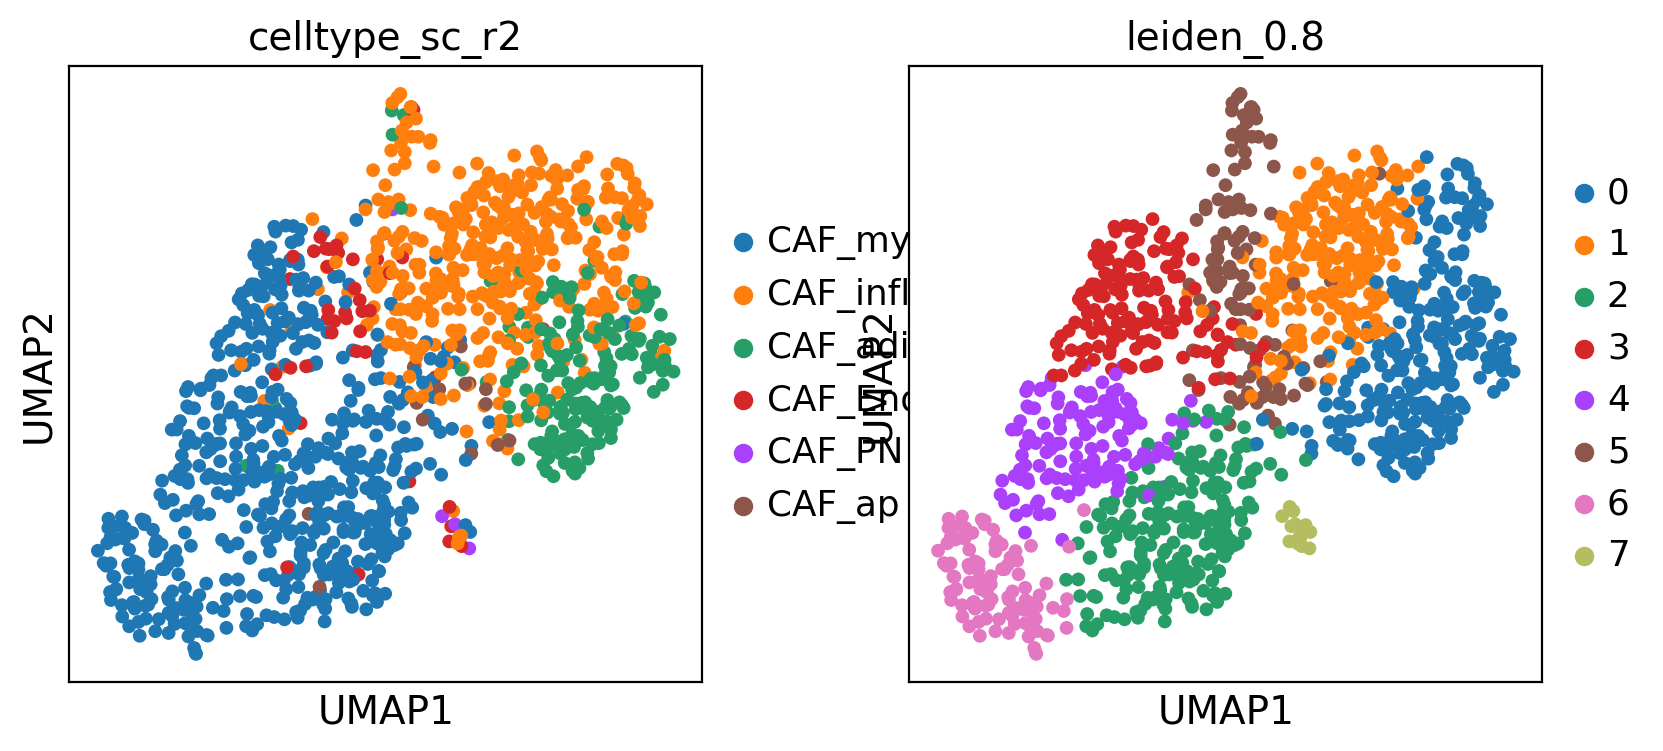

/bigdata/zlin/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


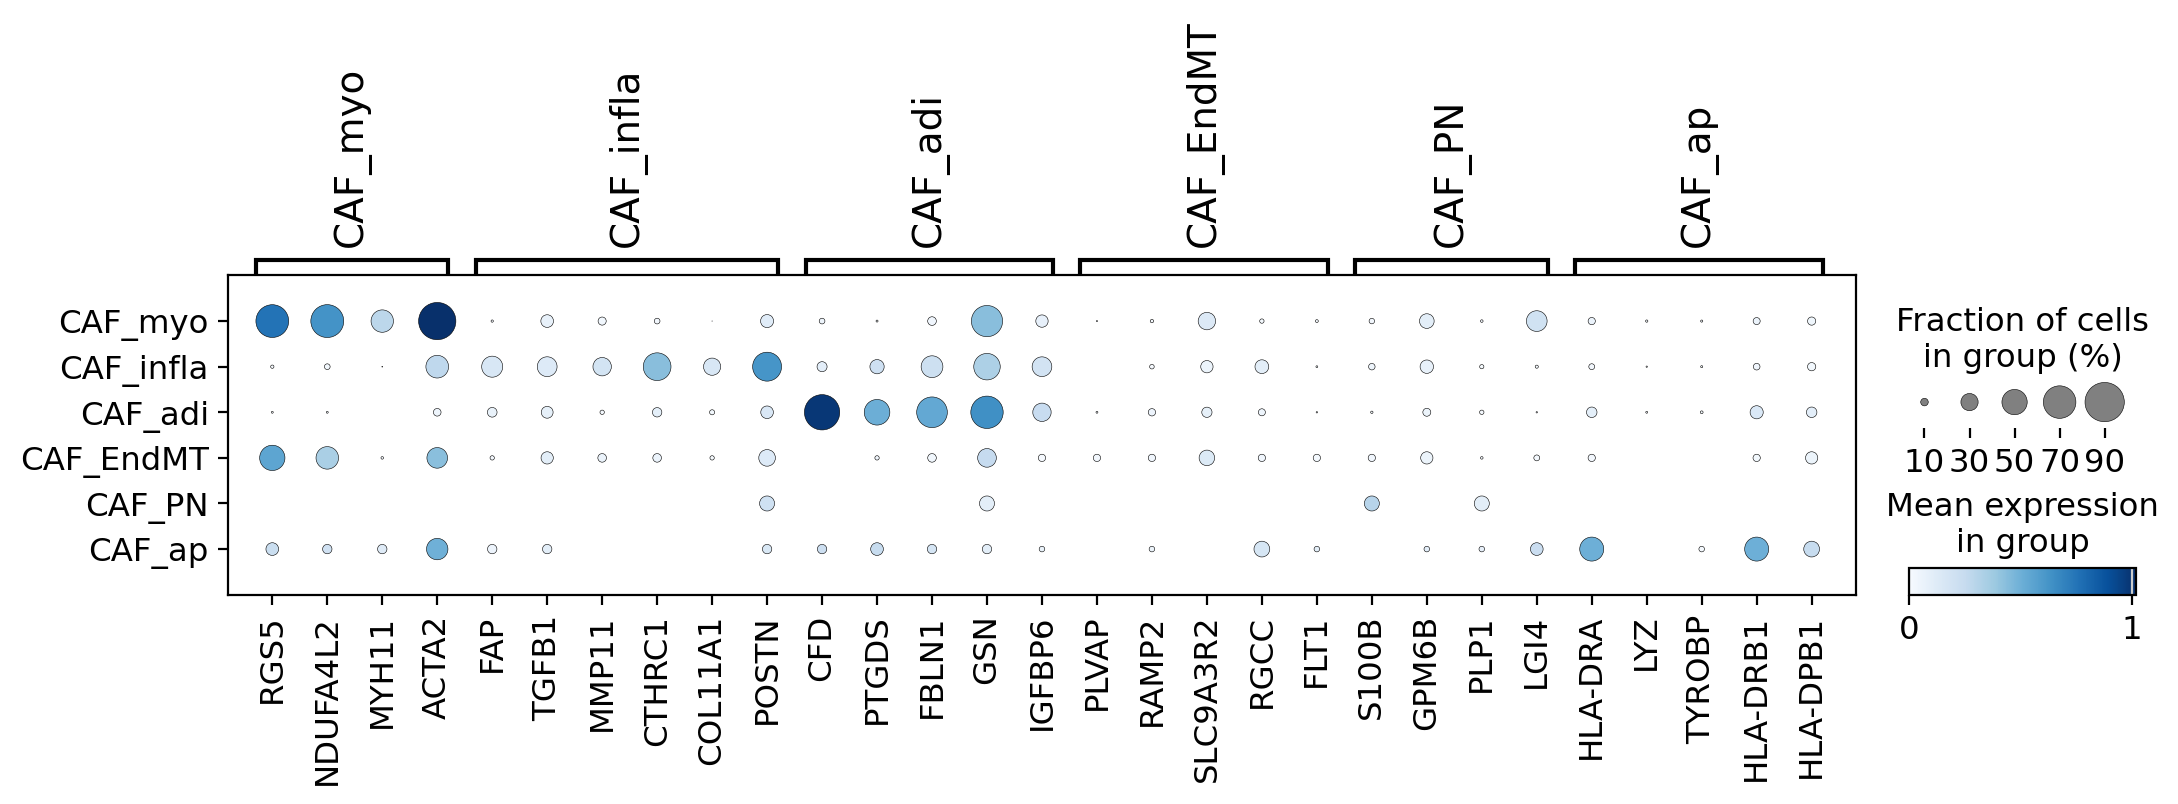

/bigdata/zlin/miniconda3/envs/scanpy_env/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


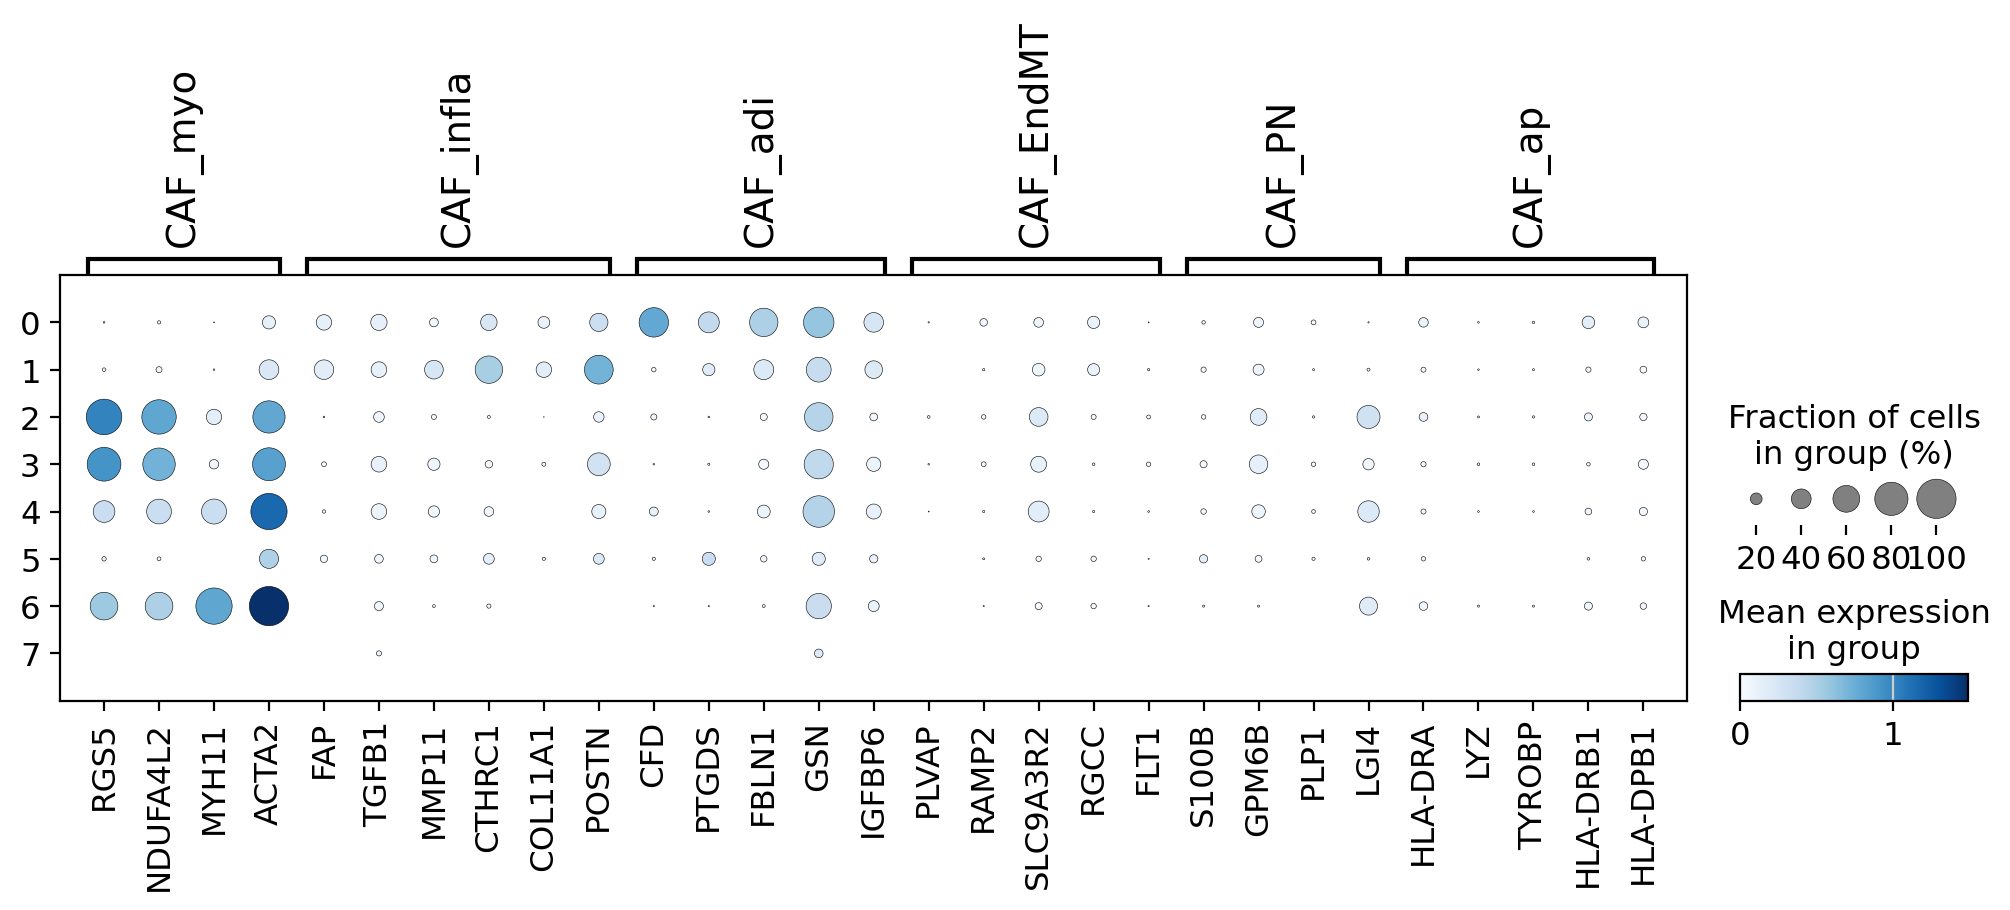

In [22]:
marker_genes_dict = {
    'CAF_myo':['RGS5','NDUFA4L2','MYH11','ACTA2'],
    'CAF_infla':['FAP','TGFB1','MMP11','CTHRC1','COL11A1','POSTN'],
    'CAF_adi':['CFD','PTGDS','FBLN1','GSN','IGFBP6'],
    'CAF_EndMT':['PLVAP','RAMP2','SLC9A3R2','RGCC','FLT1'],
    'CAF_PN':['S100B','GPM6B','PLP1','LGI4'],
    'CAF_ap': ['HLA-DRA','LYZ','TYROBP','HLA-DRB1','HLA-DPB1']
}
new_categories = ['CAF_myo', 'CAF_infla', 'CAF_adi', 'CAF_EndMT', 'CAF_PN', 'CAF_ap']
new_dtype = pd.CategoricalDtype(categories=new_categories, ordered=True)
datasets[0].obs['celltype_sc_r2'] = datasets[0].obs['celltype_sc_r2'].astype(new_dtype)
sc.pl.umap(datasets[0], color=['celltype_sc_r2','leiden_0.8'])
sc.pl.dotplot(datasets[0], marker_genes_dict, groupby='celltype_sc_r2', cmap='Blues',dendrogram=False)

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


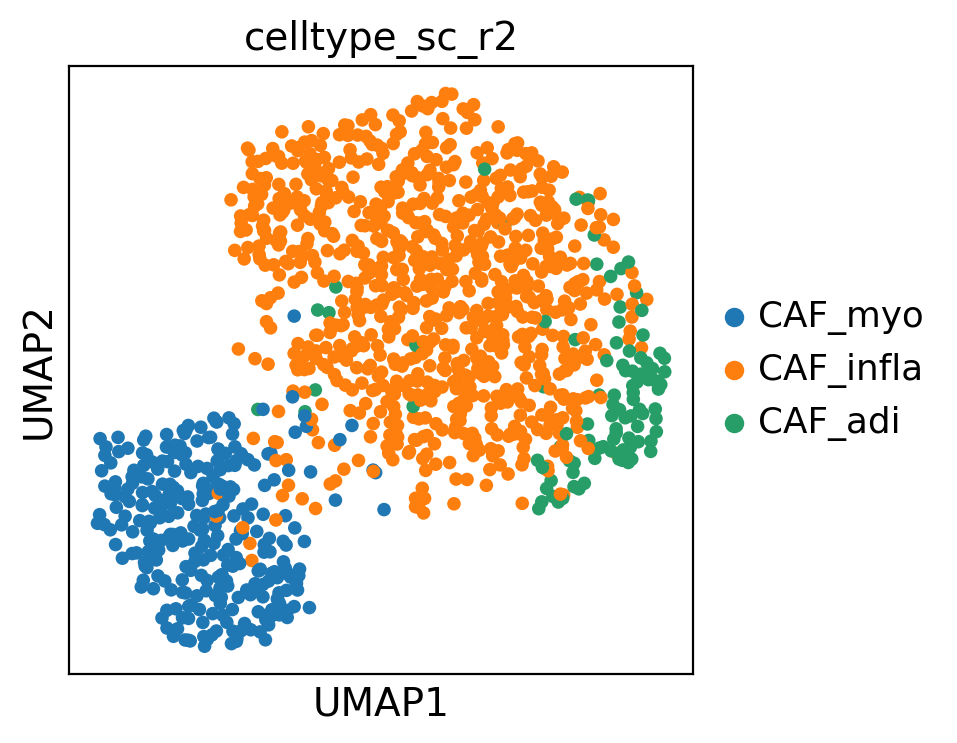

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


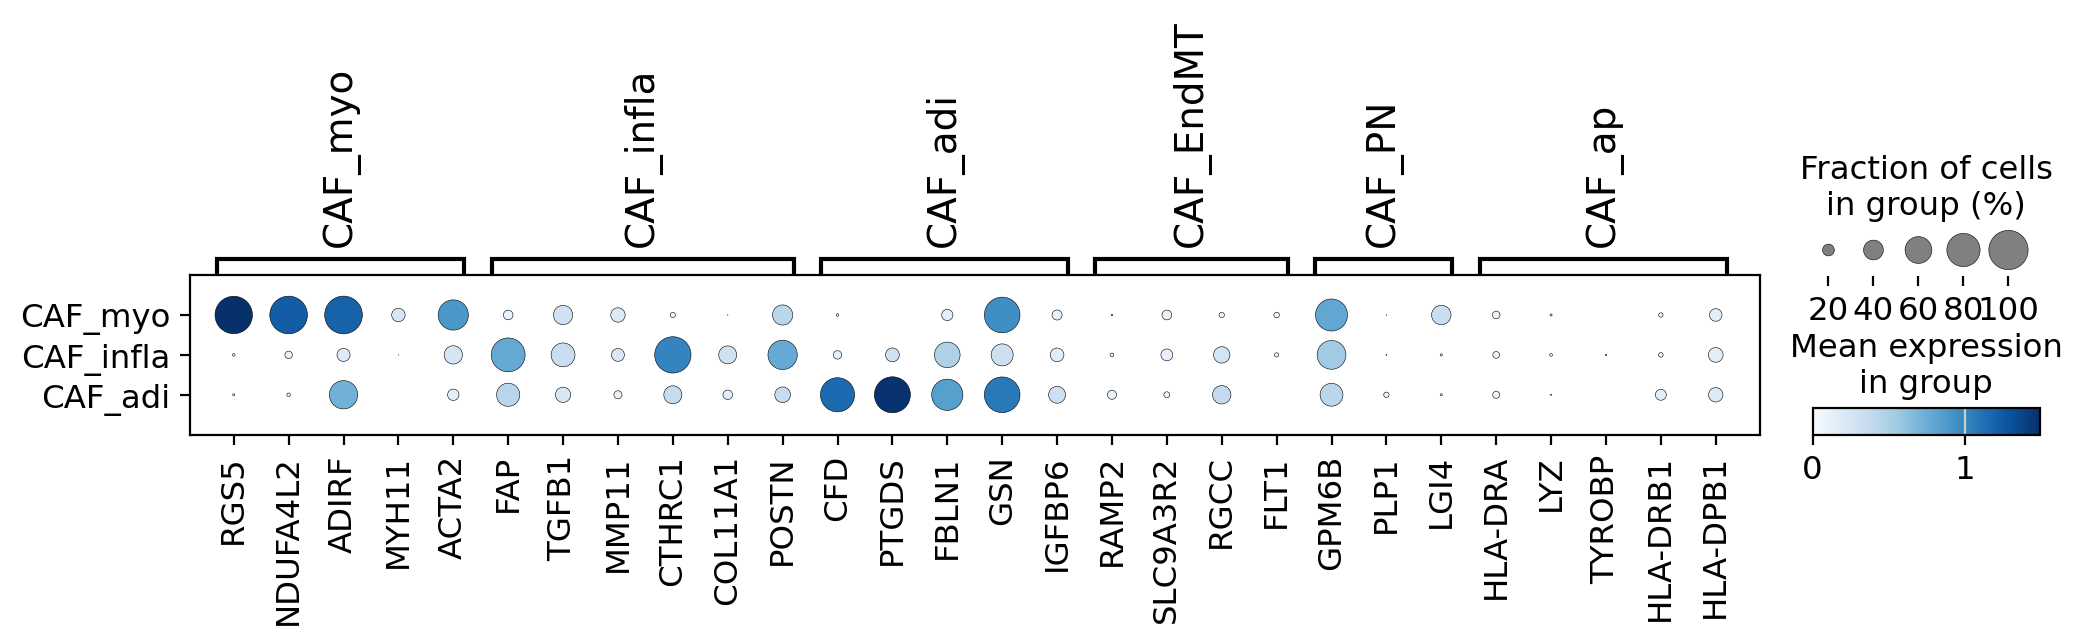

In [22]:
marker_genes_dict = {
    'CAF_myo':['RGS5','NDUFA4L2','ADIRF','MYH11','ACTA2'],
    'CAF_infla':['FAP','TGFB1','MMP11','CTHRC1','COL11A1','POSTN'],
    'CAF_adi':['CFD','PTGDS','FBLN1','GSN','IGFBP6'],
    'CAF_EndMT':['RAMP2','SLC9A3R2','RGCC','FLT1'],
    'CAF_PN':['GPM6B','PLP1','LGI4'],
    'CAF_ap': ['HLA-DRA','LYZ','TYROBP','HLA-DRB1','HLA-DPB1']
}
new_categories = ['CAF_myo', 'CAF_infla', 'CAF_adi', 'CAF_EndMT', 'CAF_PN', 'CAF_ap','unresolved']
new_dtype = pd.CategoricalDtype(categories=new_categories, ordered=True)
dataset_list[1].obs['celltype_sc_r2'] = dataset_list[1].obs['celltype_sc_r2'].astype(new_dtype)
sc.pl.umap(dataset_list[1][~dataset_list[1].obs['celltype_sc_r2'].isin(['CAF_EndMT', 'CAF_PN', 'CAF_ap','unresolved'])], color='celltype_sc_r2')
sc.pl.dotplot(dataset_list[1][~dataset_list[1].obs['celltype_sc_r2'].isin(['CAF_EndMT', 'CAF_PN', 'CAF_ap','unresolved'])], marker_genes_dict, groupby='celltype_sc_r2', cmap='Blues',dendrogram=False)

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


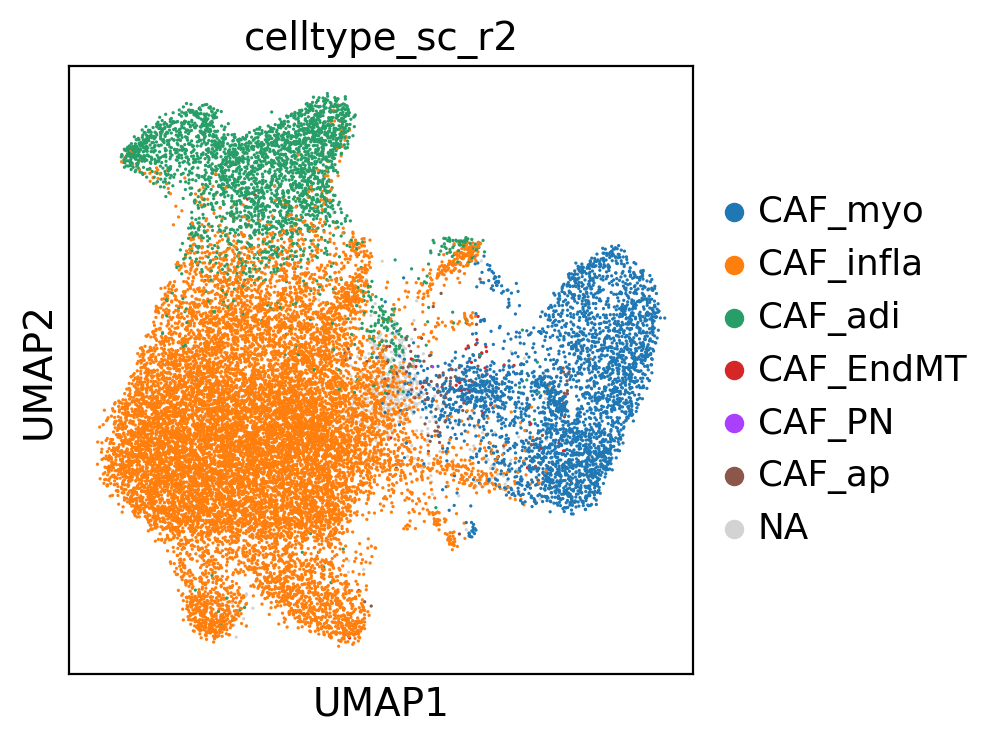

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


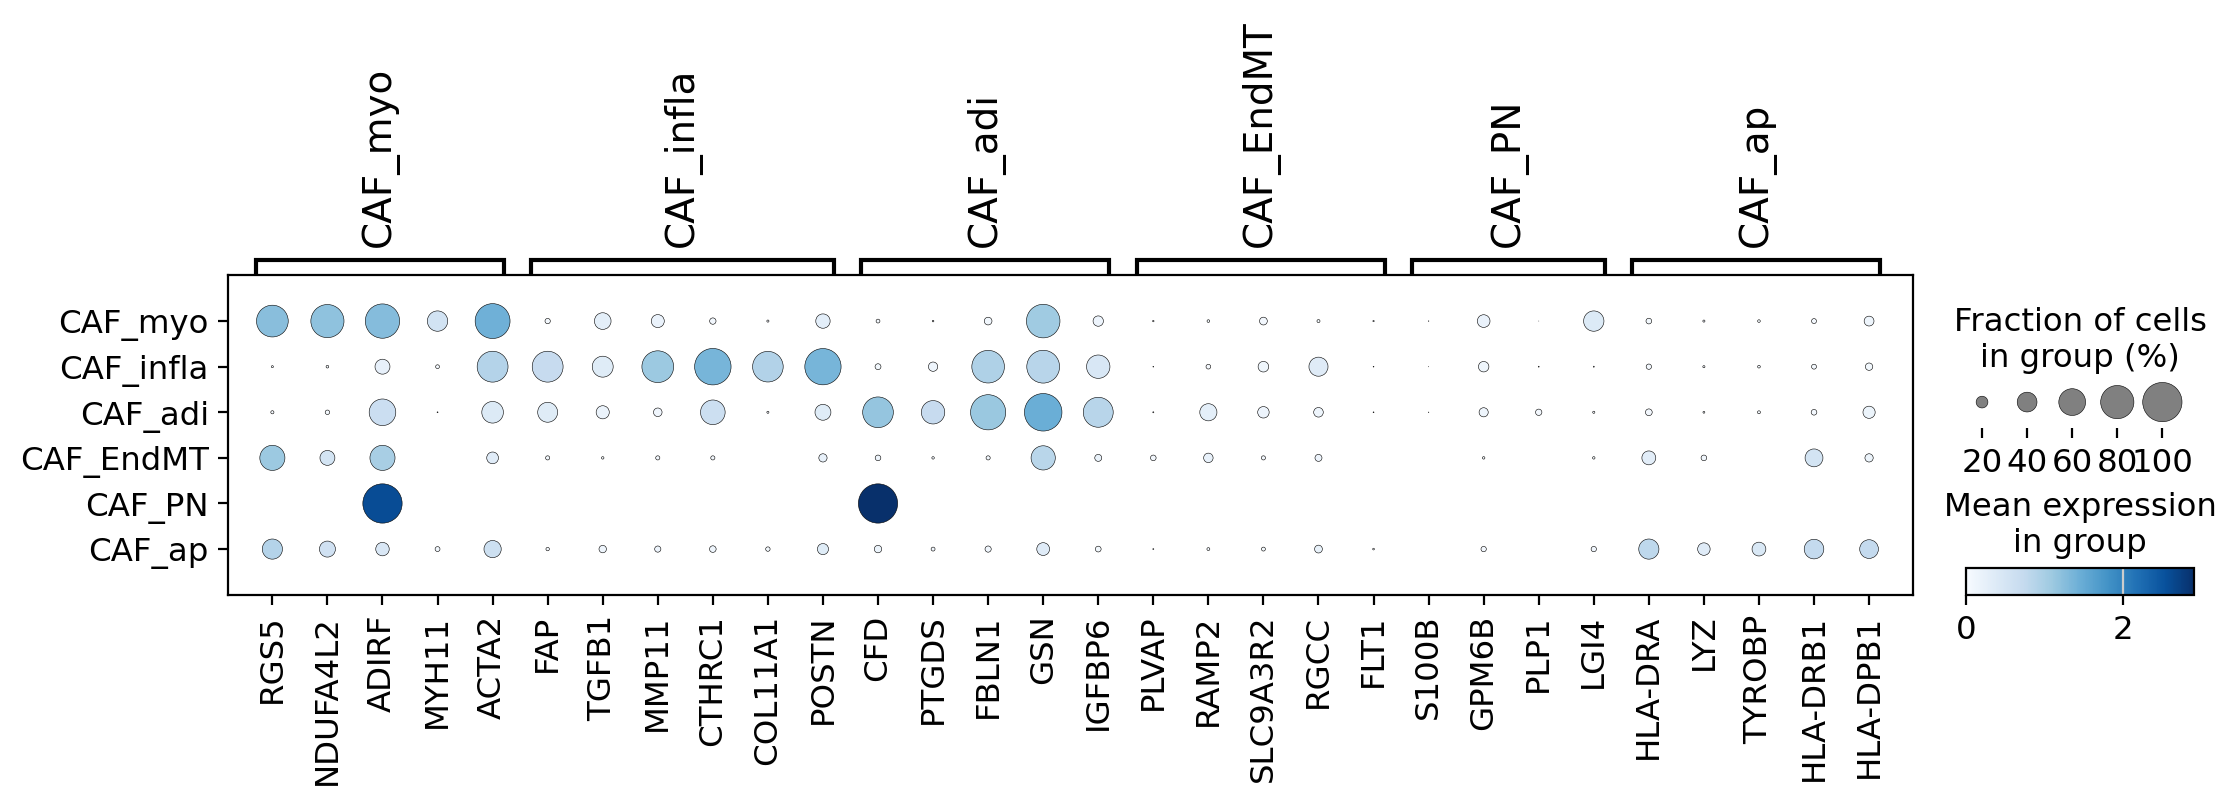

In [9]:
marker_genes_dict = {
    'CAF_myo':['RGS5','NDUFA4L2','ADIRF','MYH11','ACTA2'],
    'CAF_infla':['FAP','TGFB1','MMP11','CTHRC1','COL11A1','POSTN'],
    'CAF_adi':['CFD','PTGDS','FBLN1','GSN','IGFBP6'],
    'CAF_EndMT':['PLVAP','RAMP2','SLC9A3R2','RGCC','FLT1'],
    'CAF_PN':['S100B','GPM6B','PLP1','LGI4'],
    'CAF_ap': ['HLA-DRA','LYZ','TYROBP','HLA-DRB1','HLA-DPB1']
}
new_categories = ['CAF_myo', 'CAF_infla', 'CAF_adi', 'CAF_EndMT', 'CAF_PN', 'CAF_ap','unresolved']
new_dtype = pd.CategoricalDtype(categories=new_categories, ordered=True)
dataset_list[2].obs['celltype_sc_r2'] = dataset_list[2].obs['celltype_sc_r2'].astype(new_dtype)
sc.pl.umap(dataset_list[2], color='celltype_sc_r2')
sc.pl.dotplot(dataset_list[2], marker_genes_dict, groupby='celltype_sc_r2', cmap='Blues',dendrogram=False)

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


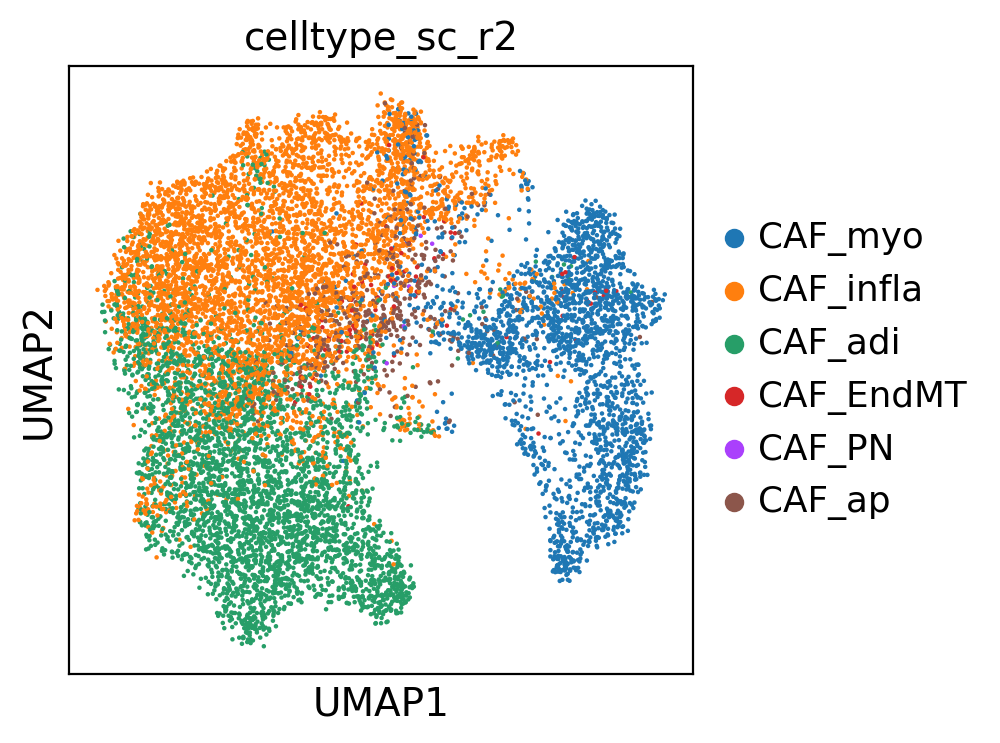

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


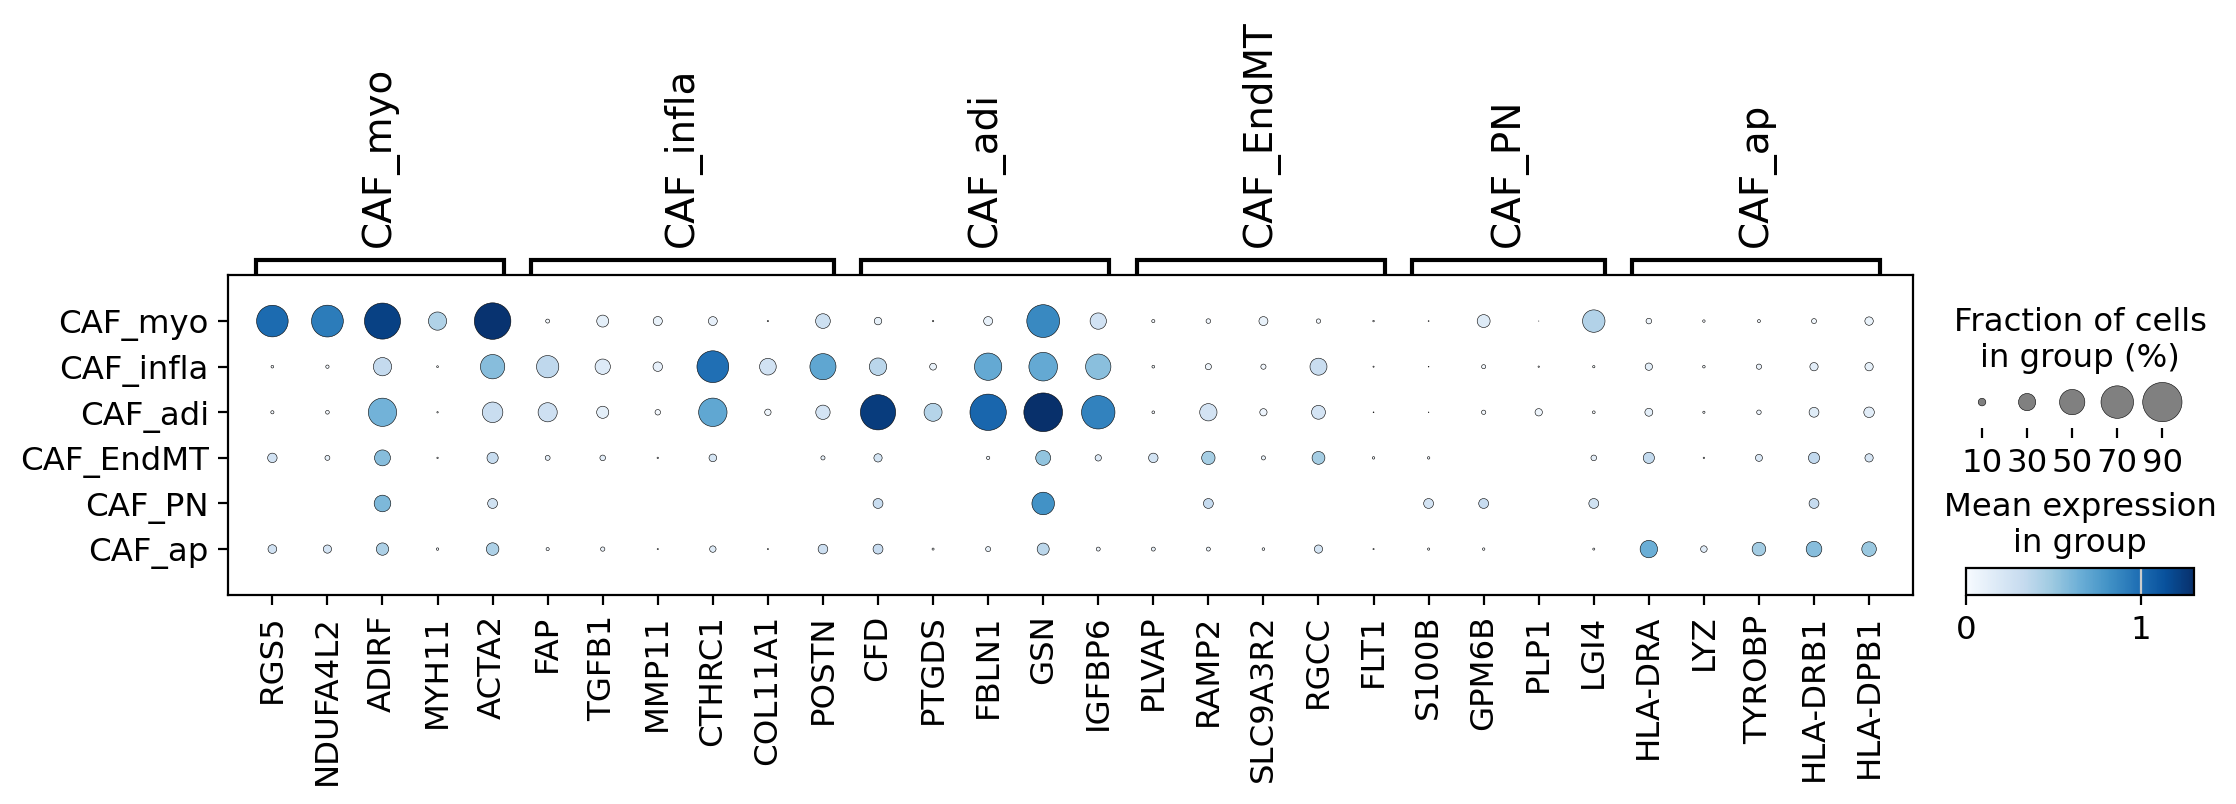

In [10]:
marker_genes_dict = {
    'CAF_myo':['RGS5','NDUFA4L2','ADIRF','MYH11','ACTA2'],
    'CAF_infla':['FAP','TGFB1','MMP11','CTHRC1','COL11A1','POSTN'],
    'CAF_adi':['CFD','PTGDS','FBLN1','GSN','IGFBP6'],
    'CAF_EndMT':['PLVAP','RAMP2','SLC9A3R2','RGCC','FLT1'],
    'CAF_PN':['S100B','GPM6B','PLP1','LGI4'],
    'CAF_ap': ['HLA-DRA','LYZ','TYROBP','HLA-DRB1','HLA-DPB1']
}
new_categories = ['CAF_myo', 'CAF_infla', 'CAF_adi', 'CAF_EndMT', 'CAF_PN', 'CAF_ap']
new_dtype = pd.CategoricalDtype(categories=new_categories, ordered=True)
dataset_list[3].obs['celltype_sc_r2'] = dataset_list[3].obs['celltype_sc_r2'].astype(new_dtype)
sc.pl.umap(dataset_list[3], color='celltype_sc_r2')
sc.pl.dotplot(dataset_list[3], marker_genes_dict, groupby='celltype_sc_r2', cmap='Blues',dendrogram=False)

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


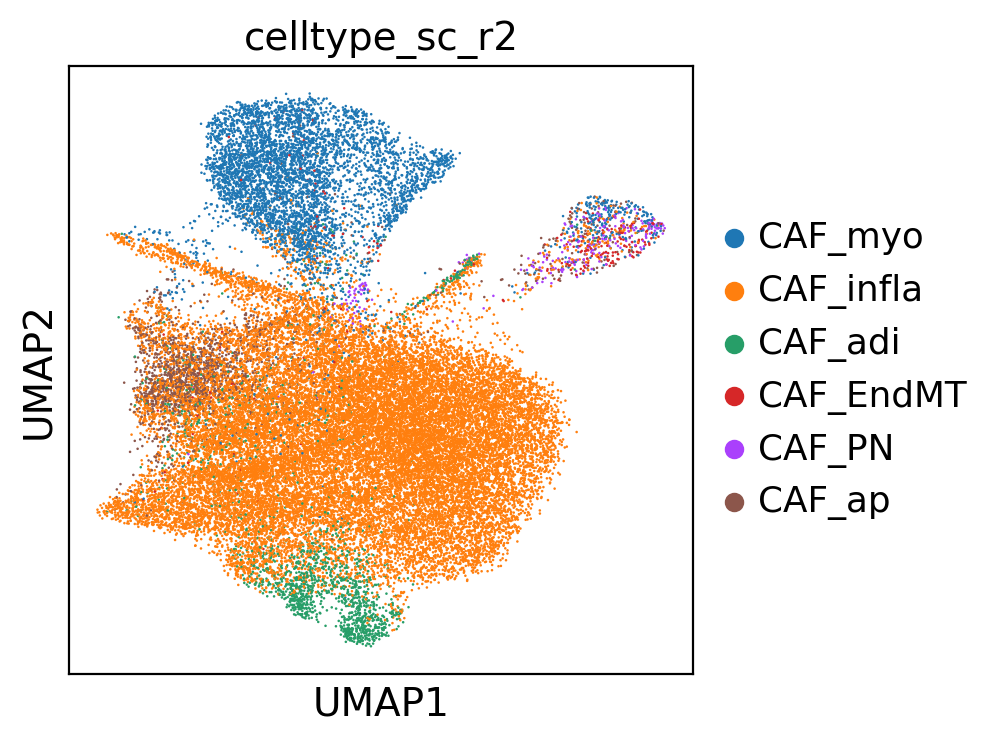

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


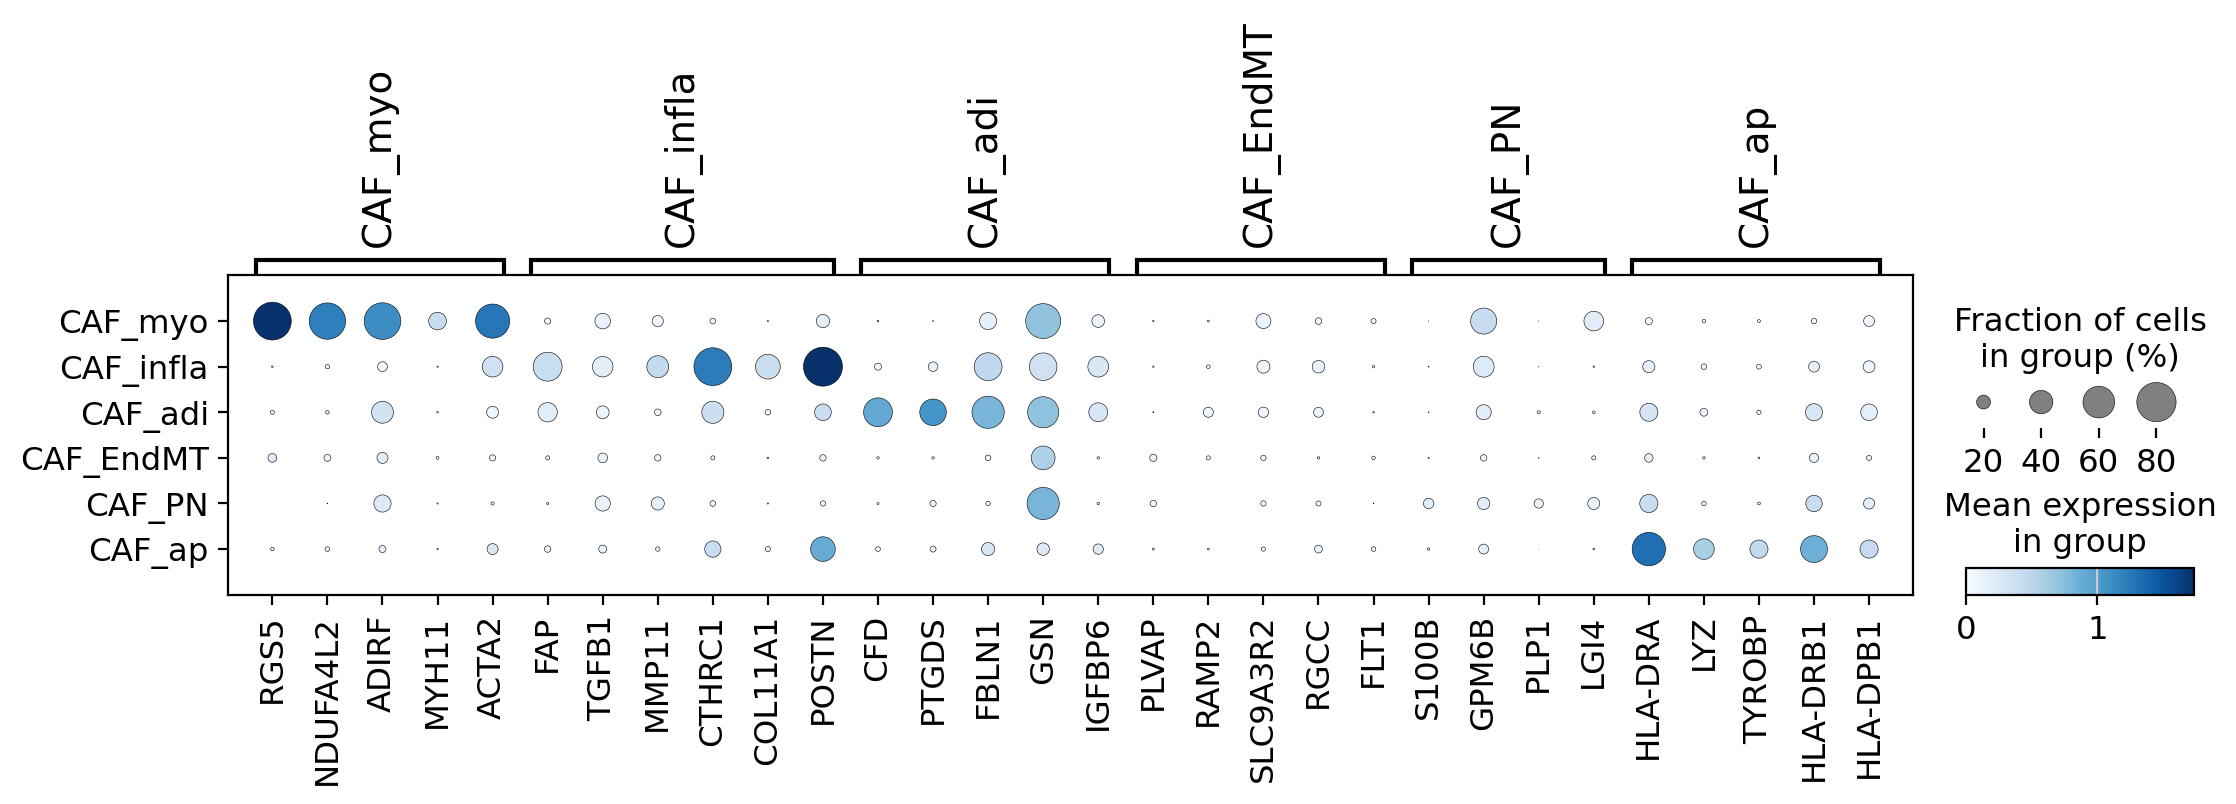

In [11]:
marker_genes_dict = {
    'CAF_myo':['RGS5','NDUFA4L2','ADIRF','MYH11','ACTA2'],
    'CAF_infla':['FAP','TGFB1','MMP11','CTHRC1','COL11A1','POSTN'],
    'CAF_adi':['CFD','PTGDS','FBLN1','GSN','IGFBP6'],
    'CAF_EndMT':['PLVAP','RAMP2','SLC9A3R2','RGCC','FLT1'],
    'CAF_PN':['S100B','GPM6B','PLP1','LGI4'],
    'CAF_ap': ['HLA-DRA','LYZ','TYROBP','HLA-DRB1','HLA-DPB1']
}
new_categories = ['CAF_myo', 'CAF_infla', 'CAF_adi', 'CAF_EndMT', 'CAF_PN', 'CAF_ap']
new_dtype = pd.CategoricalDtype(categories=new_categories, ordered=True)
dataset_list[4].obs['celltype_sc_r2'] = dataset_list[4].obs['celltype_sc_r2'].astype(new_dtype)
sc.pl.umap(dataset_list[4], color='celltype_sc_r2')
sc.pl.dotplot(dataset_list[4], marker_genes_dict, groupby='celltype_sc_r2', cmap='Blues',dendrogram=False)

In [23]:
pd.crosstab(dataset_list[2].obs['sample'],dataset_list[2].obs['celltype_sc_r2'])

celltype_sc_r2,CAF_myo,CAF_infla,CAF_adi,CAF_EndMT,CAF_PN,CAF_ap
sample,,,,,,
BIOKEY_10_On,32,170,2,0,0,8
BIOKEY_10_Pre,65,271,0,0,0,9
BIOKEY_11_On,14,30,1,0,0,0
BIOKEY_11_Pre,10,19,8,0,0,0
BIOKEY_12_On,31,140,78,0,0,1
BIOKEY_12_Pre,123,274,40,2,0,3
BIOKEY_14_On,43,52,17,0,0,1
BIOKEY_14_Pre,205,117,106,4,0,12
BIOKEY_15_On,10,40,28,0,0,2


In [24]:
pd.crosstab(dataset_list[3].obs['sample'],dataset_list[3].obs['celltype_sc_r2'])

celltype_sc_r2,CAF_myo,CAF_infla,CAF_adi,CAF_EndMT,CAF_PN,CAF_ap
sample,,,,,,
BIOKEY_32_On,88,1,282,6,0,0
BIOKEY_32_Pre,64,37,30,0,0,0
BIOKEY_33_On,122,93,22,1,0,24
BIOKEY_33_Pre,79,69,29,2,0,31
BIOKEY_34_On,62,373,153,5,1,31
BIOKEY_34_Pre,23,38,18,0,0,3
BIOKEY_35_On,44,74,25,4,0,13
BIOKEY_35_Pre,39,22,15,2,1,16
BIOKEY_36_On,221,1542,859,36,0,229


In [25]:
pd.crosstab(dataset_list[4].obs['sample'],dataset_list[4].obs['celltype_sc_r2'])

celltype_sc_r2,CAF_myo,CAF_infla,CAF_adi,CAF_EndMT,CAF_PN,CAF_ap
sample,,,,,,
1_On,56,440,45,1,0,3
1_Pre,131,588,39,0,4,3
10_On,56,478,11,1,1,9
10_Pre,252,700,96,36,10,9
11_On,7,7,10,0,0,2
11_Pre,87,175,41,2,4,11
12_On,134,439,239,9,23,87
12_Pre,147,1562,32,10,26,57
13_On,79,477,71,2,0,7
